# Working in the Frequency Domain
Created By: Prof. Hoople for GENG 360

This Jupyter notebook is designed to give you some familiarity with how to work with frequency data. 

In [1]:
# As alwayw, we start by importing our libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch # We'll need this for power spectral density estimation 

# Allow for interactive plotting in Jupyter notebooks, comment out to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package.
%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors 

# Flute Data
We'll start this activity with some data of a flute playing a note.

## Import the Data

In [2]:
flute = pd.read_csv("C:\\Users\\bexte\\Geng 360 shtuff\\geng360-konecky\\Lab 2 - Arduino DAQ\\flute.csv") # You may need to adjust the path to where your CSV file is located.
flute.head() #This will display the first few rows of the DataFrame

,Raw
0,-0.000131
1,-0.000148
2,-0.000156
3,-0.000140
4,-0.000135


## Listen to the data
Before doing any analysis, let's listen to hear what this data sounds like. 

In [3]:
# This data was sampled at 48,000 Hz, so we set the sampling frequency.
fs_flute = 48000

# Next we scale the signal from -1 to 1 so we can hear it properly.
# This is necessary because the sounddevice library expects audio data to be in this range.
flute['Scaled'] = flute['Raw'] / np.max(np.abs(flute['Raw']))
sd.play(flute['Scaled'], fs_flute) #Play the scaled flute sound
sd.wait() # Wait until the sound has finished playing before proceeding

# Plot the data
Now let's plot the data in the time domain. Run this section and a plot will appear! 

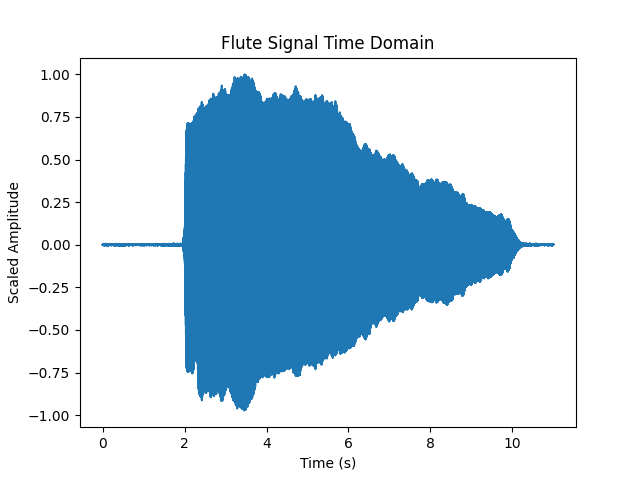

In [4]:
# Create a time vector based on the sampling rate
flute['Time (s)'] = np.arange(0, len(flute)/fs_flute, 1/fs_flute)
# The arange function has inputs (start, stop, step).

# Plot the data
plt.figure()  #Create a new figure
sns.lineplot(x="Time (s)", y="Scaled", data=flute)
plt.title('Flute Signal Time Domain')
plt.ylabel("Scaled Amplitude")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor
plt.show()  # Show the plot


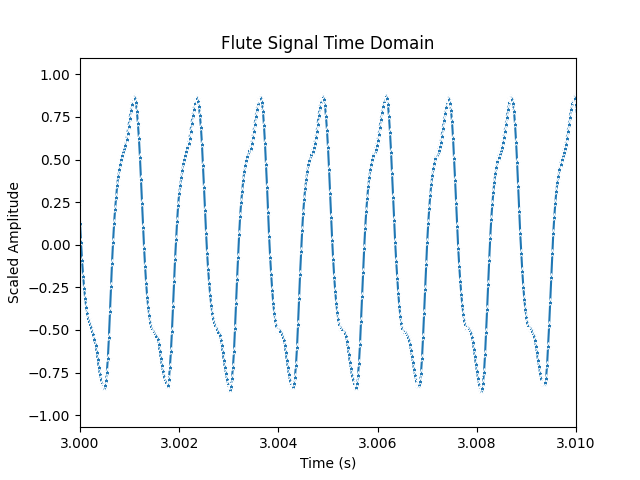

In [5]:
# Now let's create a zoomed in plot on a very small portion of the time domain signal
plt.figure()  #Create a new figure
sns.lineplot(x="Time (s)", y="Scaled", marker = "*", data=flute)
plt.title('Flute Signal Time Domain')
plt.ylabel("Scaled Amplitude")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
# Click anywhere on your data to add a cursor
# Right-click to remove a cursor
plt.xlim([3, 3.01])
plt.show()  # Show the plot


## Questions
Does this data looks like something that you could analyze using the frequency domain? Why?

Yes because there is time data that we can look at to translate and understand the frequency domain. 

Based on the time domain signal, how many peaks would you expect to see in the frequency domain? Why?

I would assume 1 or 2 because there is a consistent peak but it is not consistent.

What do the stars on the plot represent?

The stars represent the individual data points. 

## Create a power spectral density plot
We'll use Python's welch function to create a power spectral density plot as we discussed in class.

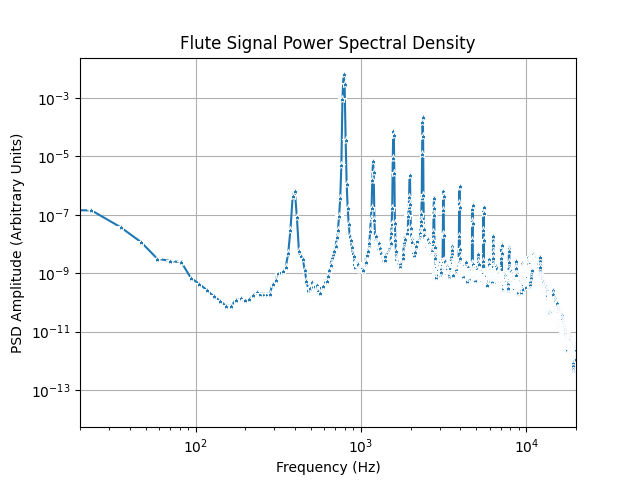

In [7]:
# Definte input parameters for Welch's method
segment_size = 4096 # Size of each segment for Welch's method, should be a power of 2 (e.g. 256, 512, 1024, 2048, 4096)
overlap_pct = 60 # Percentage of overlap between segments, typically 25-75%
overlap_size = int(segment_size * overlap_pct / 100) # Calculate the number of samples to overlap between segments

# Compute Power Spectral Density using Welch's method
f, pxx = welch(flute['Scaled'].values, 
               fs=fs_flute, window="hann", nperseg=segment_size, noverlap=overlap_size)
#f, pxx = welch(flute['Scaled'], fs=fs_flute, window="hann", nperseg=segment_size, noverlap=overlap_size)

# f is the frequency vector, pxx is the power spectral density estimate
# For more details, see the documentation https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html

plt.figure()
sns.lineplot(x=f, y=pxx, marker = '*')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Flute Signal Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

## Questions

Adjust the segment size in the code and genereate the plot several times. What differences do you observe when you use the smallest segment size vs. the biggest? 

The number of data points changed as the segment size changed. Decreasing the segment size made fewer points that were more spread out. Opposite with Increasing.

Why wouldn't you always want to use the largest segment size? 

It could be too much for the computer to handle. 

Choose your segment size as 4096. Add a tag to the highest peak. What note & octave does that correspond to from a flute? See https://mixbutton.com/music-tools/frequency-and-pitch/music-note-to-frequency-chart#1st. 

B octave 8. 

# Noisy Data
Now let's turn our attention to some "random" noise data. Here' you'll have to apply what you learned from above. 

## Import & Listen
Fill in the code below to import the data and play it 

In [8]:
noise = pd.read_csv('noise.csv') # Add code to import the data
print(noise.head())  # Display the first few rows of the DataFrame to see what variables are present. 

   Time (s)    Noise1    Noise2
0   0.00000 -0.000038  0.227068
1   0.00005 -0.000100 -0.154418
2   0.00010 -0.000167  0.133989
3   0.00015 -0.000198 -0.380282
4   0.00020 -0.000138 -0.005798


Now fill in the code below to listen to this data

In [9]:

fs_noise = 1/(noise['Time (s)'].iloc[1] - noise['Time (s)'].iloc[0])  # Calculate the sampling frequency based on the time column

sd.play(noise['Noise1'], fs_noise) #Play the scaled noise1
sd.wait() # Wait until the sound has finished playing before proceeding
sd.play(noise['Noise2'], fs_noise) #Play the scaled noise2
sd.wait() # Wait until the sound has finished playing before proceeding

## Questions
What differences can you hear between the two data sets?


Noise 1 is a lower frequency than Noise 2. Noise 2 has a higher pitch. 


## Time Domain Plot
Now let's create a time domain plot. Fill in the code below to plot the two data sets using subplots. 

In [10]:
# Check package versions
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

import scipy
print(f"SciPy version: {scipy.__version__}")

NumPy version: 2.4.2
Pandas version: 2.2.3
Matplotlib version: 3.10.8
Seaborn version: 0.13.2
SciPy version: 1.17.0


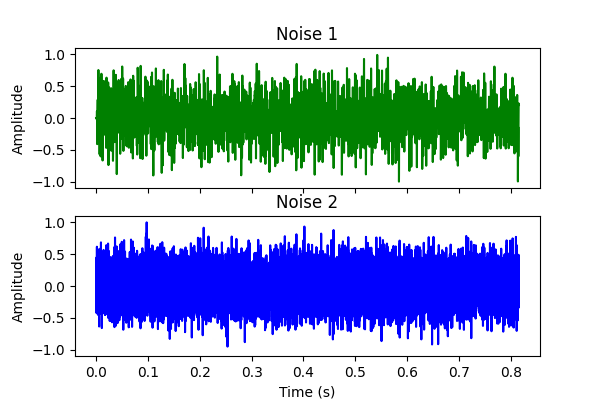

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True, sharey=True)

# Fill in the missing values for the line plots
#Noise 1
sns.lineplot(x="Time (s)", y="Noise1", data=noise, color = "green", linestyle="-", ax=ax[0])

#Noise 2
sns.lineplot(x="Time (s)", y="Noise2", data=noise, color = "blue", linestyle="-", ax=ax[1])

ax[0].set_title("Noise 1")
ax[1].set_title("Noise 2")
ax[0].set_ylabel("Amplitude")
ax[1].set_ylabel("Amplitude")
ax[1].set_xlabel("Time (s)")

plt.show()

## Questions 
Try zooming in using the interactive plot tools. What differences can you see between the signals when plotted in the time domain? 

The first noise has much more spread out signals. The second signal has much more frequent and sharp peaks. 

How does that difference relate to what you can hear? 

Lower frequencies have a deeper tone like in sound 1 whereas sound 2 has high frequencies on top of low frequencies which gives it higher tones. 

## Moving to the Frequency Domain
Now let's convert the signals to the frequency domain. Adapt the code above for the flute to create a plot that shows the power spectral density for these two signals on the same axis. 

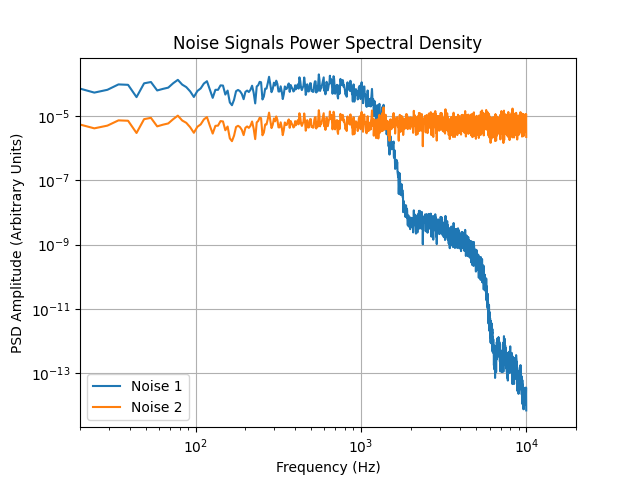

In [13]:
# Definte input parameters for Welch's method
noise_segment_size = 4096 # Size of each segment for Welch's method, should be a power of 2 (e.g. 256, 512, 1024, 2048, 4096)
noise_overlap_pct = 60 # Percentage of overlap between segments, typically 25-75%
noise_overlap_size = int(noise_segment_size * noise_overlap_pct / 100) # Calculate the number of samples to overlap between segments


# Compute Power Spectral Density using Welch's method
f_noise1, pxx_noise1 = f, pxx = welch(noise['Noise1'].values, fs=fs_noise, window="hann", nperseg=segment_size, noverlap=overlap_size)
f_noise2, pxx_noise2 = f, pxx = welch(noise['Noise2'].values, fs=fs_noise, window="hann", nperseg=segment_size, noverlap=overlap_size)

plt.figure()
sns.lineplot(x=f_noise1, y=pxx_noise1, label='Noise 1')
sns.lineplot(x=f_noise2, y=pxx_noise2, label='Noise 2')
plt.xscale('log')  # Logarithmic scale for frequency axis
plt.yscale('log')  # Logarithmic scale for power spectral density
plt.xlim([20, 20000])  # Limit x-axis to typical audio frequency range
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD Amplitude (Arbitrary Units)')
plt.title('Noise Signals Power Spectral Density')
plt.grid(True)
mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection
plt.show()

## Questions
Looking at your frequency domain plot, can you now tell the difference between the two signals? How does this compare to what you heard with your ears?

Yes, the difference can be seen that one is higher but rolls of with lower frequencies and the other has a constant frequencies. This was heard in the different pitches heard during the noises. 

One signal is louder than the other (has more power). How can you tell that from the PSD plot? 

The blue one has more power or is louder which can be seen as a higher fluctuation on the plot. 

# Submit On Canvas
Export your notebook as an HTML file and submit on Canvas. (Click the ... at the top of the notebook file and choose export) 